# MALTO Hackathon

### Libraries Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from lightgbm import LGBMClassifier
import warnings

### EDA

In [2]:
df=pd.read_csv("./data/train.csv")

In [3]:
print(f'Training set sample\n {df.head()}')
print()
print(f'Training set size {df.shape}')

Training set sample
                                                 TEXT  LABEL
0  Dear state senator, There should be a change i...      0
1  A star's life cycle begins in a nebula and pro...      1
2  Limiting the usage of has a variety advantages...      0
3  Biodiversity loss accelerates at unprecedented...      3
4  The morning had been cold. The hours dawn stil...      0

Training set size (2400, 2)


In [4]:
df.isna().sum()

TEXT     0
LABEL    0
dtype: int64

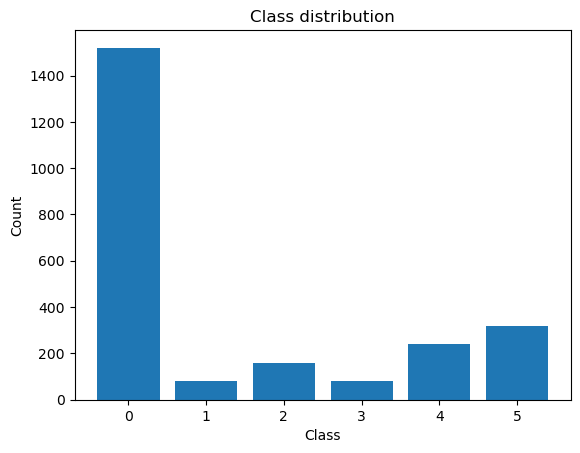

In [5]:
label_count= df["LABEL"].value_counts().sort_index()
plt.bar(label_count.index, label_count.values)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class distribution")
plt.show()

In [6]:
df["TEXT"].duplicated().sum()

0

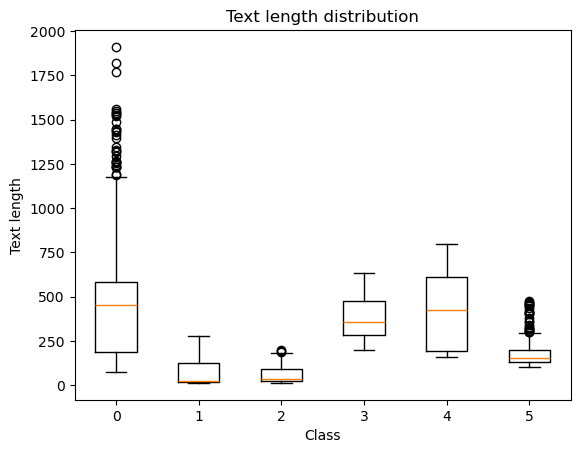

In [7]:
word_lengths = df["TEXT"].apply(lambda x: len(x.split()))
labels = sorted(df["LABEL"].unique())
data = [word_lengths[df["LABEL"] == l]for l in labels]

plt.figure()
plt.boxplot(data)
plt.xticks(range(1, len(labels)+1), labels)
plt.xlabel("Class")
plt.ylabel("Text length")
plt.title("Text length distribution")
plt.show()

### Preprocessing and Model Evaluation

In [8]:
warnings.filterwarnings("ignore")

df["TEXT_LEN"] = df["TEXT"].apply(len)
df["WORD_COUNT"] = df["TEXT"].apply(lambda x: len(str(x).split()))

X = df[["TEXT", "TEXT_LEN", "WORD_COUNT"]]
y = df["LABEL"]


preprocessor = ColumnTransformer(
    transformers=[
        ("tfidf", TfidfVectorizer(
            ngram_range=(1, 2),
            max_features=15000, 
            sublinear_tf=True,
            stop_words="english"
        ), "TEXT"),
        ("scaler", StandardScaler(), ["TEXT_LEN", "WORD_COUNT"])
    ]
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", LGBMClassifier(
        class_weight="balanced", 
        random_state=42,
        n_jobs=-1,
        verbose=-1 
    ))
])

param_grid = {
    "clf__n_estimators": [500, 600], 
    "clf__learning_rate": [0.05],
    "clf__max_depth": [6],
    "clf__num_leaves": [25, 31, 35], 
    "clf__reg_lambda": [1.5, 2.5],
    "clf__reg_alpha": [0.1, 0.2],
    "clf__subsample": [0.8],
    "clf__colsample_bytree": [0.8],
    "clf__min_child_samples": [20, 25] 
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X, y)

print(f"Best Cross-Val F1-Macro: {grid_search.best_score_}")
print(f"Best hyperparameters: {grid_search.best_params_.items()}")

best_model = grid_search.best_estimator_

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Cross-Val F1-Macro: 0.9294665970350436
Best hyperparameters: dict_items([('clf__colsample_bytree', 0.8), ('clf__learning_rate', 0.05), ('clf__max_depth', 6), ('clf__min_child_samples', 25), ('clf__n_estimators', 500), ('clf__num_leaves', 25), ('clf__reg_alpha', 0.1), ('clf__reg_lambda', 2.5), ('clf__subsample', 0.8)])


### Result Submission

In [9]:
test_df = pd.read_csv("./data/test.csv")
test_df["TEXT_LEN"] = test_df["TEXT"].apply(len)
test_df["WORD_COUNT"] = test_df["TEXT"].apply(lambda x: len(str(x).split()))

X_test = test_df[["TEXT", "TEXT_LEN", "WORD_COUNT"]]

predictions = best_model.predict(X_test)

submission_df = pd.DataFrame({
    "ID": test_df.index,   
    "LABEL": predictions
})

submission_df.to_csv("submission.csv", index=False)
print(submission_df.head())

   ID  LABEL
0   0      0
1   1      0
2   2      0
3   3      0
4   4      0
